In [1]:
import rebound
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import signal
import heyoka as hy
from celmech import Poincare, PoincareHamiltonian
from celmech.disturbing_function import laplace_b, df_coefficient_Ctilde, evaluate_df_coefficient_dict
import symengine as se
import time
import sympy as sp

In [2]:
#constants and helper functions
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

#from celmech docs
def get_pomega(kap,eta):
    return np.arctan2(-eta,kap)

def get_ecc(kap,eta,L):
    P = (kap**2 + eta**2)/2
    return np.sqrt(1 - (1 - P/L)**2)

In [3]:

def hk_integrate(pham,sim_time,num_data_points):
    #H_num = pham.H.subs(dict(pham.H_params))
    H_se = se.sympify(pham.H)
    clean_params_se = {se.sympify(k): v for k, v in dict(pham.H_params).items()
                   if not (hasattr(v, '__float__') and np.isnan(float(v)))}
    H_num = H_se.subs(clean_params_se)
    nan_symbols = {s: 0 for s in H_num.free_symbols 
               if str(s) not in {'Lambda1', 'Lambda2', 'eta1', 'eta2', 
                                  'kappa1', 'kappa2', 'lambda1', 'lambda2',
                                  'rho1', 'rho2', 'sigma1', 'sigma2'}}
    H_num = H_num.subs(nan_symbols)

    
    rho1,rho2,sigma1,sigma2 = se.symbols('rho1 rho2 sigma1 sigma2')
    sym_map = {s: 0 for s in H_num.free_symbols if str(s) in ('rho1', 'rho2', 'sigma1', 'sigma2')}
    H_planar = H_num.subs(sym_map)
    #H_planar = H_num.subs({rho1: 0, rho2: 0, sigma1: 0, sigma2: 0})
    H_planar = se.sympify(H_planar)
    print(sorted(str(s) for s in H_planar.free_symbols))

    lam1,lam2 = se.symbols('lambda1 lambda2')
    Lam1,Lam2 = se.symbols('Lambda1 Lambda2')
    eta1,eta2 = se.symbols('eta1 eta2')
    kap1, kap2 = se.symbols('kappa1 kappa2')

    print('*** Differentiating  ***')

    sym_dict = {str(s): s for s in H_planar.free_symbols}
    lam1 = sym_dict['lambda1']
    lam2 = sym_dict['lambda2']
    Lam1 = sym_dict['Lambda1']
    Lam2 = sym_dict['Lambda2']
    eta1 = sym_dict['eta1']
    eta2 = sym_dict['eta2']
    kap1 = sym_dict['kappa1']
    kap2 = sym_dict['kappa2']

    dLam1_dt = -se.diff(H_planar, lam1)
    dLam2_dt = -se.diff(H_planar, lam2)
    dlam1_dt =  se.diff(H_planar, Lam1)
    dlam2_dt =  se.diff(H_planar, Lam2)

    deta1_dt  = se.diff(H_planar, kap1)
    dkap1_dt  =  -se.diff(H_planar, eta1)
    deta2_dt  = se.diff(H_planar, kap2)
    dkap2_dt  =  -se.diff(H_planar, eta2)

    derivs = [dlam1_dt, dLam1_dt, dlam2_dt, dLam2_dt, deta1_dt, dkap1_dt, deta2_dt, dkap2_dt]

    vars_list = [lam1, Lam1, lam2, Lam2, eta1, kap1, eta2, kap2]
    func = se.Lambdify(vars_list,H_planar)

    jup = pham.state.particles[1]
    sat = pham.state.particles[2]

    initial_conditions = [jup.l, jup.Lambda, sat.l, sat.Lambda,jup.eta, jup.kappa, sat.eta, sat.kappa]
    derivs_at_0 = func(*initial_conditions)

    lam1_hy, Lam1_hy, lam2_hy, Lam2_hy, eta1_hy, kap1_hy, eta2_hy, kap2_hy = hy.make_vars('lam1_hy', 'Lam1_hy', 'lam2_hy', 'Lam2_hy', 'eta1_hy', 'kap1_hy', 'eta2_hy', 'kap2_hy')

    eqs_hy = [hy.from_sympy(sp.sympify(eq), {sp.Symbol('lambda1'): lam1_hy, 
                                          sp.Symbol('Lambda1'): Lam1_hy,
                                          sp.Symbol('lambda2'): lam2_hy, 
                                          sp.Symbol('Lambda2'): Lam2_hy,
                                          sp.Symbol('eta1'): eta1_hy, 
                                          sp.Symbol('kappa1'): kap1_hy,
                                          sp.Symbol('eta2'): eta2_hy, 
                                          sp.Symbol('kappa2'): kap2_hy})
           for eq in derivs]

    ta = hy.taylor_adaptive(sys=[(lam1_hy, eqs_hy[0]),(Lam1_hy, eqs_hy[1]),(lam2_hy, eqs_hy[2]),(Lam2_hy, eqs_hy[3]),(eta1_hy,  eqs_hy[4]),(kap1_hy,  eqs_hy[5]),(eta2_hy,  eqs_hy[6]),(kap2_hy,  eqs_hy[7])],
    state=initial_conditions,
    high_accuracy= True,
    time=0.0,
    tol=1e-16)

    e_i = float(func(*ta.state))
    print(e_i)

    times = np.linspace(0,sim_time,int(num_data_points))*2*np.pi 
    e_sat = np.zeros(len(times))
    pomega_sat = np.zeros(len(times))
    e_j = np.zeros(len(times))
    pomega_j = np.zeros(len(times)) 
    a_sat = np.zeros(len(times))

    def get_sma(Lambda, m, M=1.0):
        return (Lambda / m) ** 2



    start = time.perf_counter()
    print('*** Starting Simulation ***')
    '''res, min_dt, max_dt, num_steps, callback, flat_states = ta.propagate_grid(times.tolist(), max_delta_t=0.01)

    flat_states = np.array(flat_states)

    num_vars = 8 
    state_matrix = flat_states.reshape(-1, num_vars)

    L_all   = state_matrix[:, 3]
    eta_all = state_matrix[:, 6]
    kap_all = state_matrix[:, 7]

    e_sat = get_ecc(kap_all, eta_all, L_all)
    pomega_sat = get_pomega(kap_all, eta_all)'''
    
    for i in tqdm(range(len(times))):
        ta.propagate_until(times[i],max_delta_t=float(10))
        L, eta, kap = ta.state[3], ta.state[6], ta.state[7]
        Lj, etaj, kapj = ta.state[1], ta.state[4], ta.state[5]
        e_sat[i] = get_ecc(kap, eta, L)
        pomega_sat[i] = get_pomega(kap, eta)
        e_j[i] = get_ecc(kapj, etaj, Lj)
        pomega_j = get_pomega(kapj, etaj)
        sat_particle = pham.state.particles[2]
        a_sat[i] = (L / sat_particle.m) ** 2

        
    end = time.perf_counter()

    e_f = float(func(*ta.state))
    print(e_f)
    e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
    print(f'Energy Percent Change: {e_per} %')
    
    print('*** Simulation Complete ***')

    print('Time elapsed  = ' + str(end-start) + ' seconds')

    return times, pomega_sat, e_sat, a_sat

In [6]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1)


a_12 = pham.state.particles[2].a
n12 = pham.state.particles[2].n

alpha12 = 5.6/8.9

sim.move_to_com()

fd_21_k4 = evaluate_df_coefficient_dict(
    df_coefficient_Ctilde(k1=2, k2=-1, k3=0, k4=-1, k5=0, k6=0,
                          nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = True), alpha12)

sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=9.19,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1)


a_2110 = pham.state.particles[2].a
n2110 = pham.state.particles[2].n

alpha2110 = 5.6/9.19

sim.move_to_com()

fd_21_10 = evaluate_df_coefficient_dict(
    df_coefficient_Ctilde(k1=21, k2=-11, k3=0, k4=-10, k5=0, k6=0,
                          nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = True), alpha2110)

def c_r(m, n, alpha):
    return m * n * alpha

c_r_21 = c_r(m_jup,n12,alpha12)
def a_max_21(e, c_r_val, fd, n, a, j2):
    x = (np.abs(c_r_val) / n) * np.abs(fd)
    return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)


['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166639314896e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:13<00:00, 7300.08it/s]
/tmp/ipykernel_10801/1495441170.py:53: RuntimeWarning: divide by zero encountered in divide
  return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)
/tmp/ipykernel_10801/1495441170.py:53: RuntimeWarning: invalid value encountered in multiply
  return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)


-8.880166639312892e-05
Energy Percent Change: 2.25718598287162e-11 %
*** Simulation Complete ***
Time elapsed  = 13.711223645997961 seconds


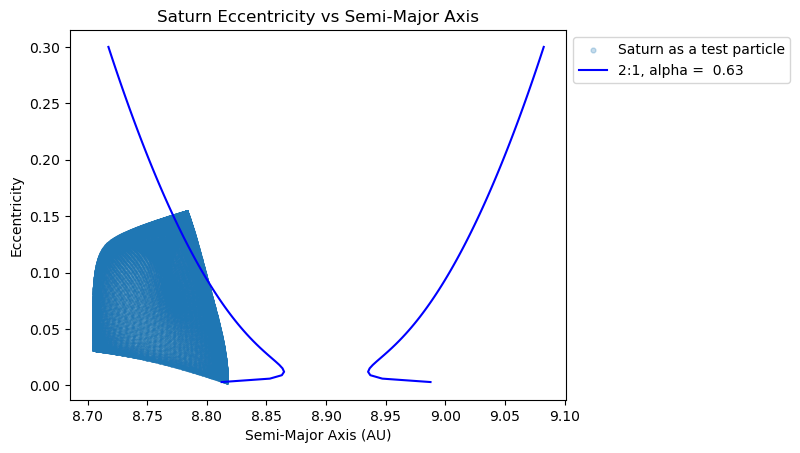

In [5]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.80,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.80

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2) 

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 1e6, 1e5)

ecc_vals = np.linspace(0,0.3,100)

plt.scatter(a_sat, e_sat, label="Saturn as a test particle", s=0.25, alpha = 0.25)
plt.plot(8.9 + a_max_21(ecc_vals, c_r_21,fd_21_k4, n12, 8.9,2),ecc_vals, color = 'blue', label = f'2:1, alpha = {alpha12: .2f}')
plt.plot(8.9 - a_max_21(ecc_vals, c_r_21,fd_21_k4, n12, 8.9,2),ecc_vals, color = 'blue')
plt.xlabel(r'Semi-Major Axis (AU)')
plt.ylabel('Eccentricity')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left',markerscale=7.0)
plt.title('Saturn Eccentricity vs Semi-Major Axis')
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166629799226e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:14<00:00, 6805.72it/s]
/tmp/ipykernel_10801/1495441170.py:53: RuntimeWarning: divide by zero encountered in divide
  return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)
/tmp/ipykernel_10801/1495441170.py:53: RuntimeWarning: invalid value encountered in multiply
  return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)


-8.880166629798379e-05
Energy Percent Change: 9.538480329996364e-12 %
*** Simulation Complete ***
Time elapsed  = 14.697378683998977 seconds


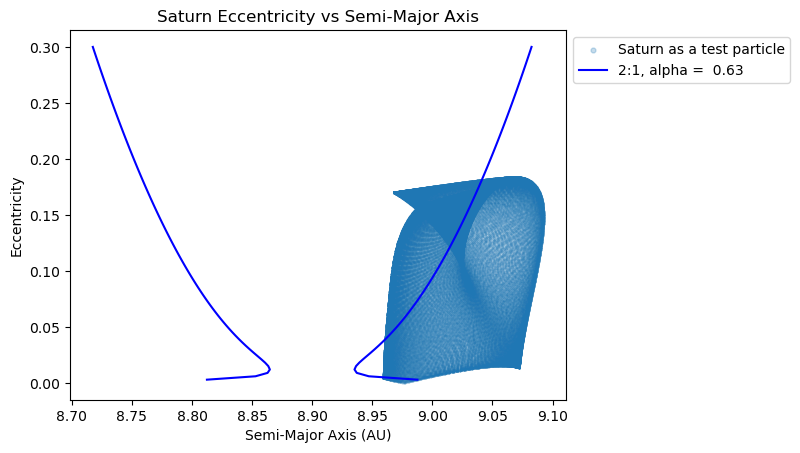

In [6]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.95,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.80

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2) 

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 1e6, 1e5)

ecc_vals = np.linspace(0,0.3,100)

plt.scatter(a_sat, e_sat, label="Saturn as a test particle", s=0.25, alpha = 0.25)
plt.plot(8.9 + a_max_21(ecc_vals, c_r_21,fd_21_k4, n12, 8.9,2),ecc_vals, color = 'blue', label = f'2:1, alpha = {alpha12: .2f}')
plt.plot(8.9 - a_max_21(ecc_vals, c_r_21,fd_21_k4, n12, 8.9,2),ecc_vals, color = 'blue')
plt.xlabel(r'Semi-Major Axis (AU)')
plt.ylabel('Eccentricity')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left',markerscale=7.0)
plt.title('Saturn Eccentricity vs Semi-Major Axis')
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634834168e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:12<00:00, 7923.58it/s]
/tmp/ipykernel_10801/1495441170.py:53: RuntimeWarning: divide by zero encountered in divide
  return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)
/tmp/ipykernel_10801/1495441170.py:53: RuntimeWarning: invalid value encountered in multiply
  return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)


-8.88016663483375e-05
Energy Percent Change: 4.700563103957049e-12 %
*** Simulation Complete ***
Time elapsed  = 12.624668209999072 seconds


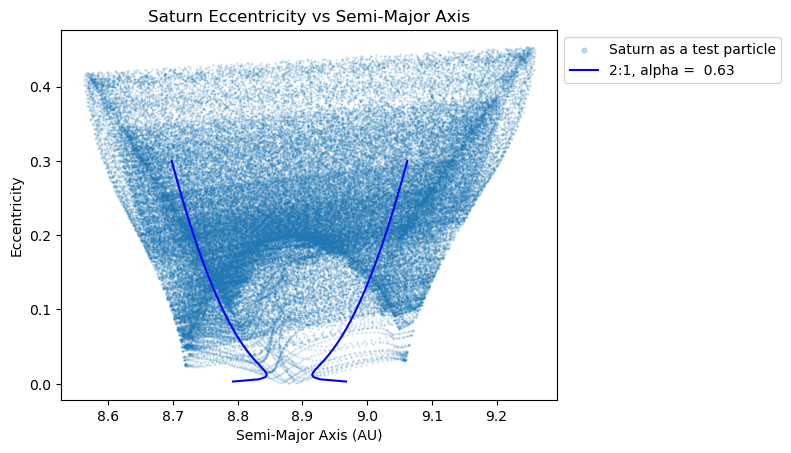

In [9]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.80

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2) 

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 1e6, 1e5)

ecc_vals = np.linspace(0,0.3,100)

plt.scatter(a_sat, e_sat, label="Saturn as a test particle", s=0.25, alpha = 0.25)
plt.plot(8.88 + a_max_21(ecc_vals, c_r_21,fd_21_k4, n12, 8.88,2),ecc_vals, color = 'blue', label = f'2:1, alpha = {alpha12: .2f}')
plt.plot(8.88 - a_max_21(ecc_vals, c_r_21,fd_21_k4, n12, 8.88,2),ecc_vals, color = 'blue')
plt.xlabel(r'Semi-Major Axis (AU)')
plt.ylabel('Eccentricity')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left',markerscale=7.0)
plt.title('Saturn Eccentricity vs Semi-Major Axis')
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166629799226e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:11<00:00, 8937.61it/s]
/tmp/ipykernel_10801/1495441170.py:53: RuntimeWarning: divide by zero encountered in divide
  return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)
/tmp/ipykernel_10801/1495441170.py:53: RuntimeWarning: invalid value encountered in multiply
  return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)


-8.880166629798379e-05
Energy Percent Change: 9.538480329996364e-12 %
*** Simulation Complete ***
Time elapsed  = 11.193403288998525 seconds


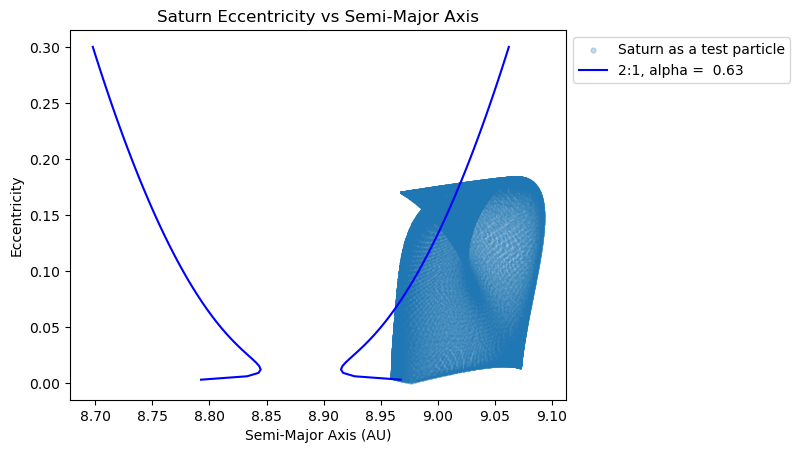

In [12]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.95,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.80

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2) 

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 1e6, 1e5)

ecc_vals = np.linspace(0,0.3,100)

plt.scatter(a_sat, e_sat, label="Saturn as a test particle", s=0.25, alpha = 0.25)
plt.plot(8.88 + a_max_21(ecc_vals, c_r_21,fd_21_k4, n12, 8.88,2),ecc_vals, color = 'blue', label = f'2:1, alpha = {alpha12: .2f}')
plt.plot(8.88 - a_max_21(ecc_vals, c_r_21,fd_21_k4, n12, 8.88,2),ecc_vals, color = 'blue')
plt.xlabel(r'Semi-Major Axis (AU)')
plt.ylabel('Eccentricity')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left',markerscale=7.0)
plt.title('Saturn Eccentricity vs Semi-Major Axis')
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166637385881e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:13<00:00, 7484.19it/s]
/tmp/ipykernel_10801/1495441170.py:53: RuntimeWarning: divide by zero encountered in divide
  return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)
/tmp/ipykernel_10801/1495441170.py:53: RuntimeWarning: invalid value encountered in multiply
  return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)


-8.880166637385676e-05
Energy Percent Change: 2.304496845758305e-12 %
*** Simulation Complete ***
Time elapsed  = 13.367887810996763 seconds


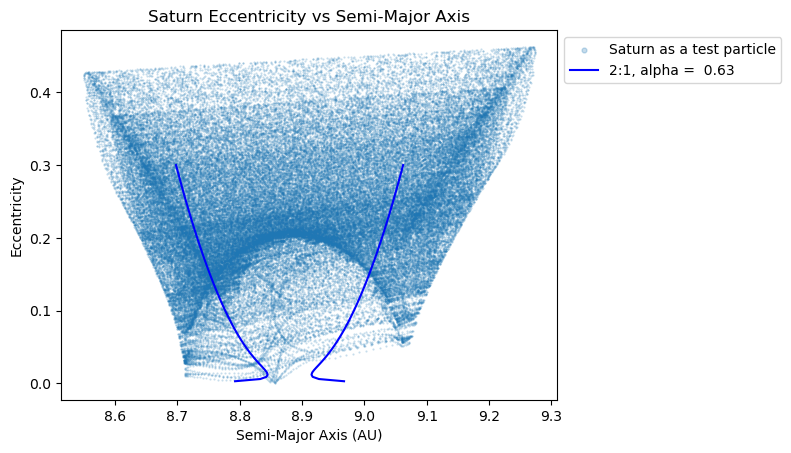

In [14]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.83,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.80

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2) 

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 1e6, 1e5)

ecc_vals = np.linspace(0,0.3,100)

plt.scatter(a_sat, e_sat, label="Saturn as a test particle", s=0.25, alpha = 0.25)
plt.plot(8.88 + a_max_21(ecc_vals, c_r_21,fd_21_k4, n12, 8.88,2),ecc_vals, color = 'blue', label = f'2:1, alpha = {alpha12: .2f}')
plt.plot(8.88 - a_max_21(ecc_vals, c_r_21,fd_21_k4, n12, 8.88,2),ecc_vals, color = 'blue')
plt.xlabel(r'Semi-Major Axis (AU)')
plt.ylabel('Eccentricity')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left',markerscale=7.0)
plt.title('Saturn Eccentricity vs Semi-Major Axis')
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166632935445e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:09<00:00, 10520.37it/s]
/tmp/ipykernel_1507/1495441170.py:53: RuntimeWarning: divide by zero encountered in divide
  return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)
/tmp/ipykernel_1507/1495441170.py:53: RuntimeWarning: invalid value encountered in multiply
  return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)


-8.880166632935463e-05
Energy Percent Change: 1.984003907938551e-13 %
*** Simulation Complete ***
Time elapsed  = 6.565762629999881 seconds


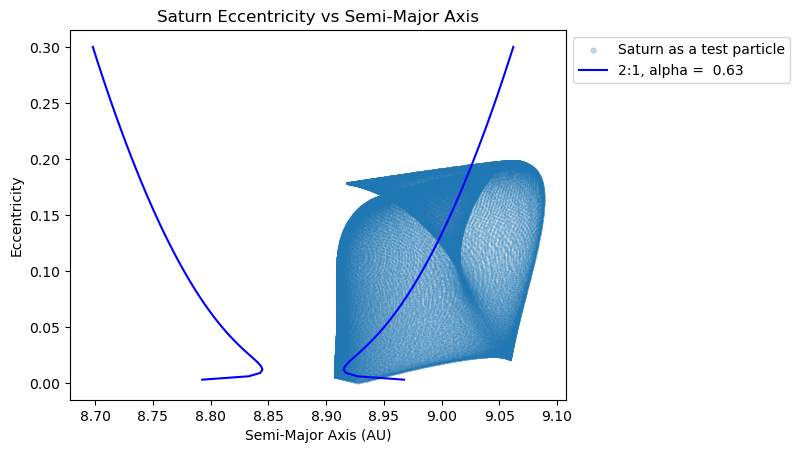

In [7]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.80

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2) 

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 1e6, 1e5)

ecc_vals = np.linspace(0,0.3,100)

plt.scatter(a_sat, e_sat, label="Saturn as a test particle", s=0.25, alpha = 0.25)
plt.plot(8.88 + a_max_21(ecc_vals, c_r_21,fd_21_k4, n12, 8.88,2),ecc_vals, color = 'blue', label = f'2:1, alpha = {alpha12: .2f}')
plt.plot(8.88 - a_max_21(ecc_vals, c_r_21,fd_21_k4, n12, 8.88,2),ecc_vals, color = 'blue')
plt.xlabel(r'Semi-Major Axis (AU)')
plt.ylabel('Eccentricity')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left',markerscale=7.0)
plt.title('Saturn Eccentricity vs Semi-Major Axis')
plt.show()